In [2]:
from google.colab import files
uploaded = files.upload()

Saving brain_tumor_dataset.zip to brain_tumor_dataset (1).zip


In [3]:
import zipfile

with zipfile.ZipFile('brain_tumor_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [5]:
data_dir = "/content/brain_tumor_dataset"

train_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.


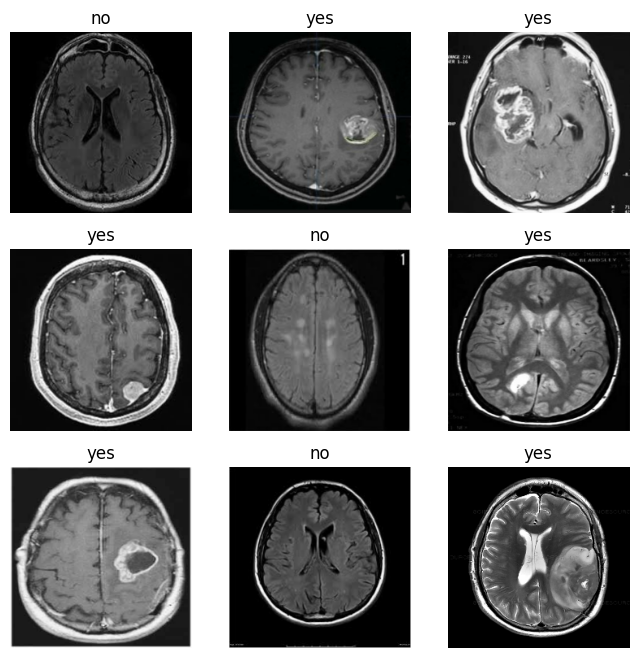

In [6]:
class_names = train_ds.class_names

plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [7]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y: (normalization_layer(x),y))
val_ds = val_ds.map(lambda x,y: (normalization_layer(x),y))

In [8]:
model = keras.Sequential([

layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
layers.MaxPooling2D(),

layers.Conv2D(64,(3,3),activation='relu'),
layers.MaxPooling2D(),

layers.Conv2D(128,(3,3),activation='relu'),
layers.MaxPooling2D(),

layers.Flatten(),

layers.Dense(128,activation='relu'),
layers.Dense(1,activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [10]:
history = model.fit(
train_ds,
validation_data=val_ds,
epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 35s 5s/step - accuracy: 0.6158 - loss: 0.8393 - val_accuracy: 0.7800 - val_loss: 0.5505
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.7537 - loss: 0.4880 - val_accuracy: 0.8000 - val_loss: 0.5514
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.8128 - loss: 0.4039 - val_accuracy: 0.8200 - val_loss: 0.5571
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8670 - loss: 0.3125 - val_accuracy: 0.7400 - val_loss: 0.6567
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9163 - loss: 0.2434 - val_accuracy: 0.8000 - val_loss: 0.5590
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9507 - loss: 0.1401 - val_accuracy: 0.8000 - val_loss: 0.5331
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9606 - loss: 0.0956 - val_accuracy: 0.8000 - val_loss: 0.7439
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9409 - loss: 0.1399 - val_accuracy: 0.8200 - val_loss: 0.5573
Epoch 9/

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 902ms/step
Tumor Detected


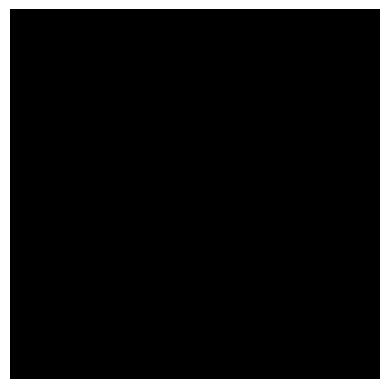

In [11]:
 for images, labels in val_ds.take(1):

    prediction = model.predict(images)

    plt.imshow(images[0].numpy().astype("uint8"))
    plt.axis('off')

    if prediction[0] > 0.5:
        print("Tumor Detected")
    else:
        print("No Tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


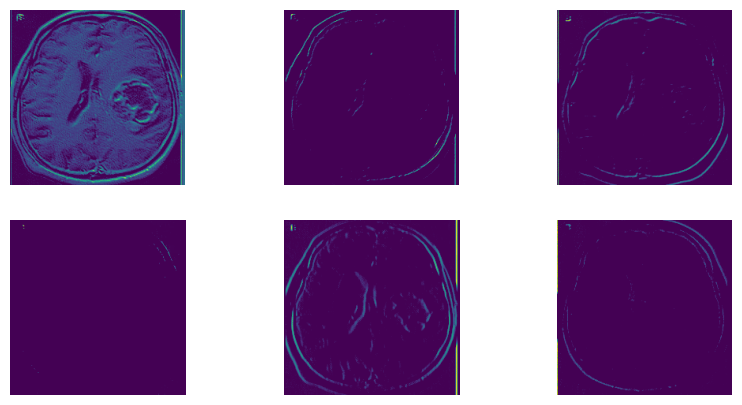

In [12]:
layer_outputs = [layer.output for layer in model.layers[:3]]

activation_model = keras.models.Model(inputs=model.inputs, outputs=layer_outputs)

sample_image = images[0:1]

activations = activation_model.predict(sample_image)

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(activations[0][0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.show()

(np.float64(-0.5), np.float64(108.5), np.float64(108.5), np.float64(-0.5))

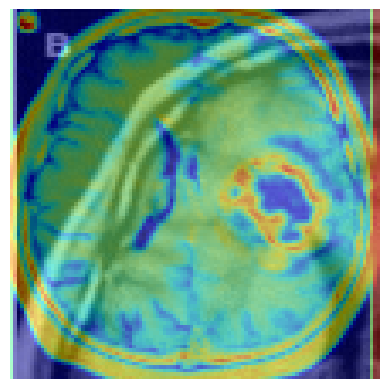

In [13]:
import cv2

img = images[0].numpy()

heatmap = np.mean(activations[-1][0], axis=-1)

heatmap = np.maximum(heatmap,0)
heatmap /= np.max(heatmap)

plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.axis('off')